# Test synthetic data function

Generates synthetic stroke patient data with a predefined causal treatment effect.

This function simulates patient demographics, clinical characteristics, treatment 
assignment (thrombolysis), and mortality outcomes. It explicitly constructs the 
causal relationships and temporal treatment effects, making it ideal for testing 
causal inference algorithms.

Args:
    n (int, optional): The number of synthetic patients to generate. Defaults to 1000.
    seed (int, optional): The random seed for reproducibility. Defaults to 42.

Returns:
    pd.DataFrame: A DataFrame containing the synthetic patient data, including 
    demographics, treatment assignments, true probabilities, causal effects, 
    and final observed outcomes.

Calculations Performed:

1. Patient Characteristics
    * Age: Uniformly distributed between 60 and 89.
    * Ethnicity: Randomly assigned as White (70%), Asian (20%), or Black (10%).
    * Sex (Male): Binomial distribution (50% probability).
    * AFib (Diagnosis): Binomial distribution (25% probability if at least age 70).
    * Warfarin Use: Binomial distribution (50% probability among AFib patients).
    * NIHSS (Stroke Severity): Triangular distribution (min=0, mode=10, max=30).
        * Add 5 to NIHSS if age > 80 to simulate higher stroke severity in older patients.
    * Shoe Size (Noise): Triangular distribution (min=5, mode=9, max=13).

2. Base Mortality Probability (Without Treatment)
    * Starts at a base probability of 0.05.
    * Adds 0.005 for every year of age over 60.
    * Adds 0.05 for male patients.
    * Add 0.02 for patients with AFib.
    * Adds 0.01 for each NIHSS point.
    * Adds 0.10 for Black patients and 0.05 for Asian patients.
    * Adds 0.10 if the patient was treated in the year 2020 (e.g. COVID-19 effect).
    * The sum is clipped to [0.001, 0.999] to prevent mathematical errors.
    * The probability is then converted to odds and log-odds.

3. Thrombolysis Treatment Assignment
    * Base probability of receiving treatment is 0.50, modified by an NIHSS weight:
        - NIHSS < 5: Weight is 0.0.
        - NIHSS 5 to 9: Ramps linearly from 0.0 to 1.0.
        - NIHSS 10 to 20: Weight remains 1.0.
        - NIHSS 21 to 30: Decreases linearly from 1.0 to 0.0.
    * Probability is forced to 0.0 if the patient is on Warfarin.
    * Final treatment status is drawn from a binomial distribution.

4. Treatment Effect (Log-Odds Ratio)
    * Time to thrombolysis is drawn uniformly between 30 and 360 minutes 
    (set to 99999 if the patient was not treated).
    * A base log-odds ratio of 2.0 is established for the treatment effect.
    * Time decay multiplier: The effect linearly decays to zero at 360 minutes 
    using the formula (360 - time) / 360.
    * Ethnicity modifier: The resulting log-odds ratio is halved for Asian patients.

5. Final Outcome (Mortality)
    * Treated Log-Odds: Calculated by subtracting the log-odds ratio from the 
    base log-odds without treatment.
    * Treated Probability: The treated log-odds are converted back to a probability.
    * Final Probability: The algorithm assigns the treated probability if the 
    patient received thrombolysis, otherwise it assigns the base untreated probability.
    * Mortality ('died'): A final binomial draw determines if the patient survives 
    or dies based on their final probability.

In [1]:
import math
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from modules.create_data import create_stroke_data

In [2]:
df = create_stroke_data(n=10000, seed=42)
df

,patient_id,year,age,ethnicity,male,afib,warfarin,shoe_size,nihss,thrombolysis_time,...,mortality_odds_no_treatment,mortality_log_odds_no_treatment,mortality_prob_treated,mortality_odds_treated,mortality_log_odds_treated,odds_ratio_treated,log_odds_ratio_treated,probability_difference,mortality_probability,died
0,1,2022,66,white,1,0,0,10,6,301.0,...,0.2346,-1.4500,0.1446,0.1690,-1.7780,1.3881,0.3279,0.0454,0.1446,0
1,2,2019,79,white,1,0,0,7,1,99999.0,...,0.2579,-1.3553,0.2050,0.2579,-1.3553,1.0000,0.0000,0.0000,0.2050,0
2,3,2024,88,white,1,0,0,9,23,99999.0,...,0.8868,-0.1201,0.4700,0.8868,-0.1201,1.0000,0.0000,0.0000,0.4700,1
3,4,2020,74,white,0,0,0,10,22,309.0,...,0.7857,-0.2412,0.3718,0.5919,-0.5245,1.3275,0.2833,0.0682,0.3718,0
4,5,2021,70,black,1,0,0,7,9,355.0,...,0.5152,-0.6633,0.3338,0.5011,-0.6910,1.0281,0.0277,0.0062,0.3338,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,2021,84,white,1,1,0,8,13,291.0,...,0.5873,-0.5322,0.2860,0.4006,-0.9147,1.4659,0.3825,0.0840,0.2860,1
9996,9997,2019,87,asian,0,0,0,11,16,99999.0,...,0.6529,-0.4263,0.3950,0.6529,-0.4263,1.0000,0.0000,-0.0000,0.3950,0
9997,9998,2024,64,white,0,0,0,11,6,99999.0,...,0.1494,-1.9010,0.1300,0.1494,-1.9010,1.0000,0.0000,-0.0000,0.1300,0
9998,9999,2018,83,white,0,0,0,10,16,99999.0,...,0.4815,-0.7309,0.3250,0.4815,-0.7309,1.0000,0.0000,0.0000,0.3250,0


In [3]:
df.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
patient_id,10000.0,5000.500,2886.896,1.000,2500.750,5000.500,7500.250,10000.000
year,10000.0,2020.971,1.990,2018.000,2019.000,2021.000,2023.000,2024.000
age,10000.0,74.728,8.656,60.000,67.000,75.000,82.000,89.000
male,10000.0,0.516,0.500,0.000,0.000,1.000,1.000,1.000
afib,10000.0,0.163,0.369,0.000,0.000,0.000,0.000,1.000
warfarin,10000.0,0.081,0.273,0.000,0.000,0.000,0.000,1.000
shoe_size,10000.0,8.498,1.665,5.000,7.000,8.000,10.000,12.000
nihss,10000.0,14.654,6.707,0.000,10.000,14.000,19.000,34.000
thrombolysis_time,10000.0,65516.197,47463.021,30.000,267.000,99999.000,99999.000,99999.000
thrombolysis,10000.0,0.346,0.476,0.000,0.000,0.000,1.000,1.000


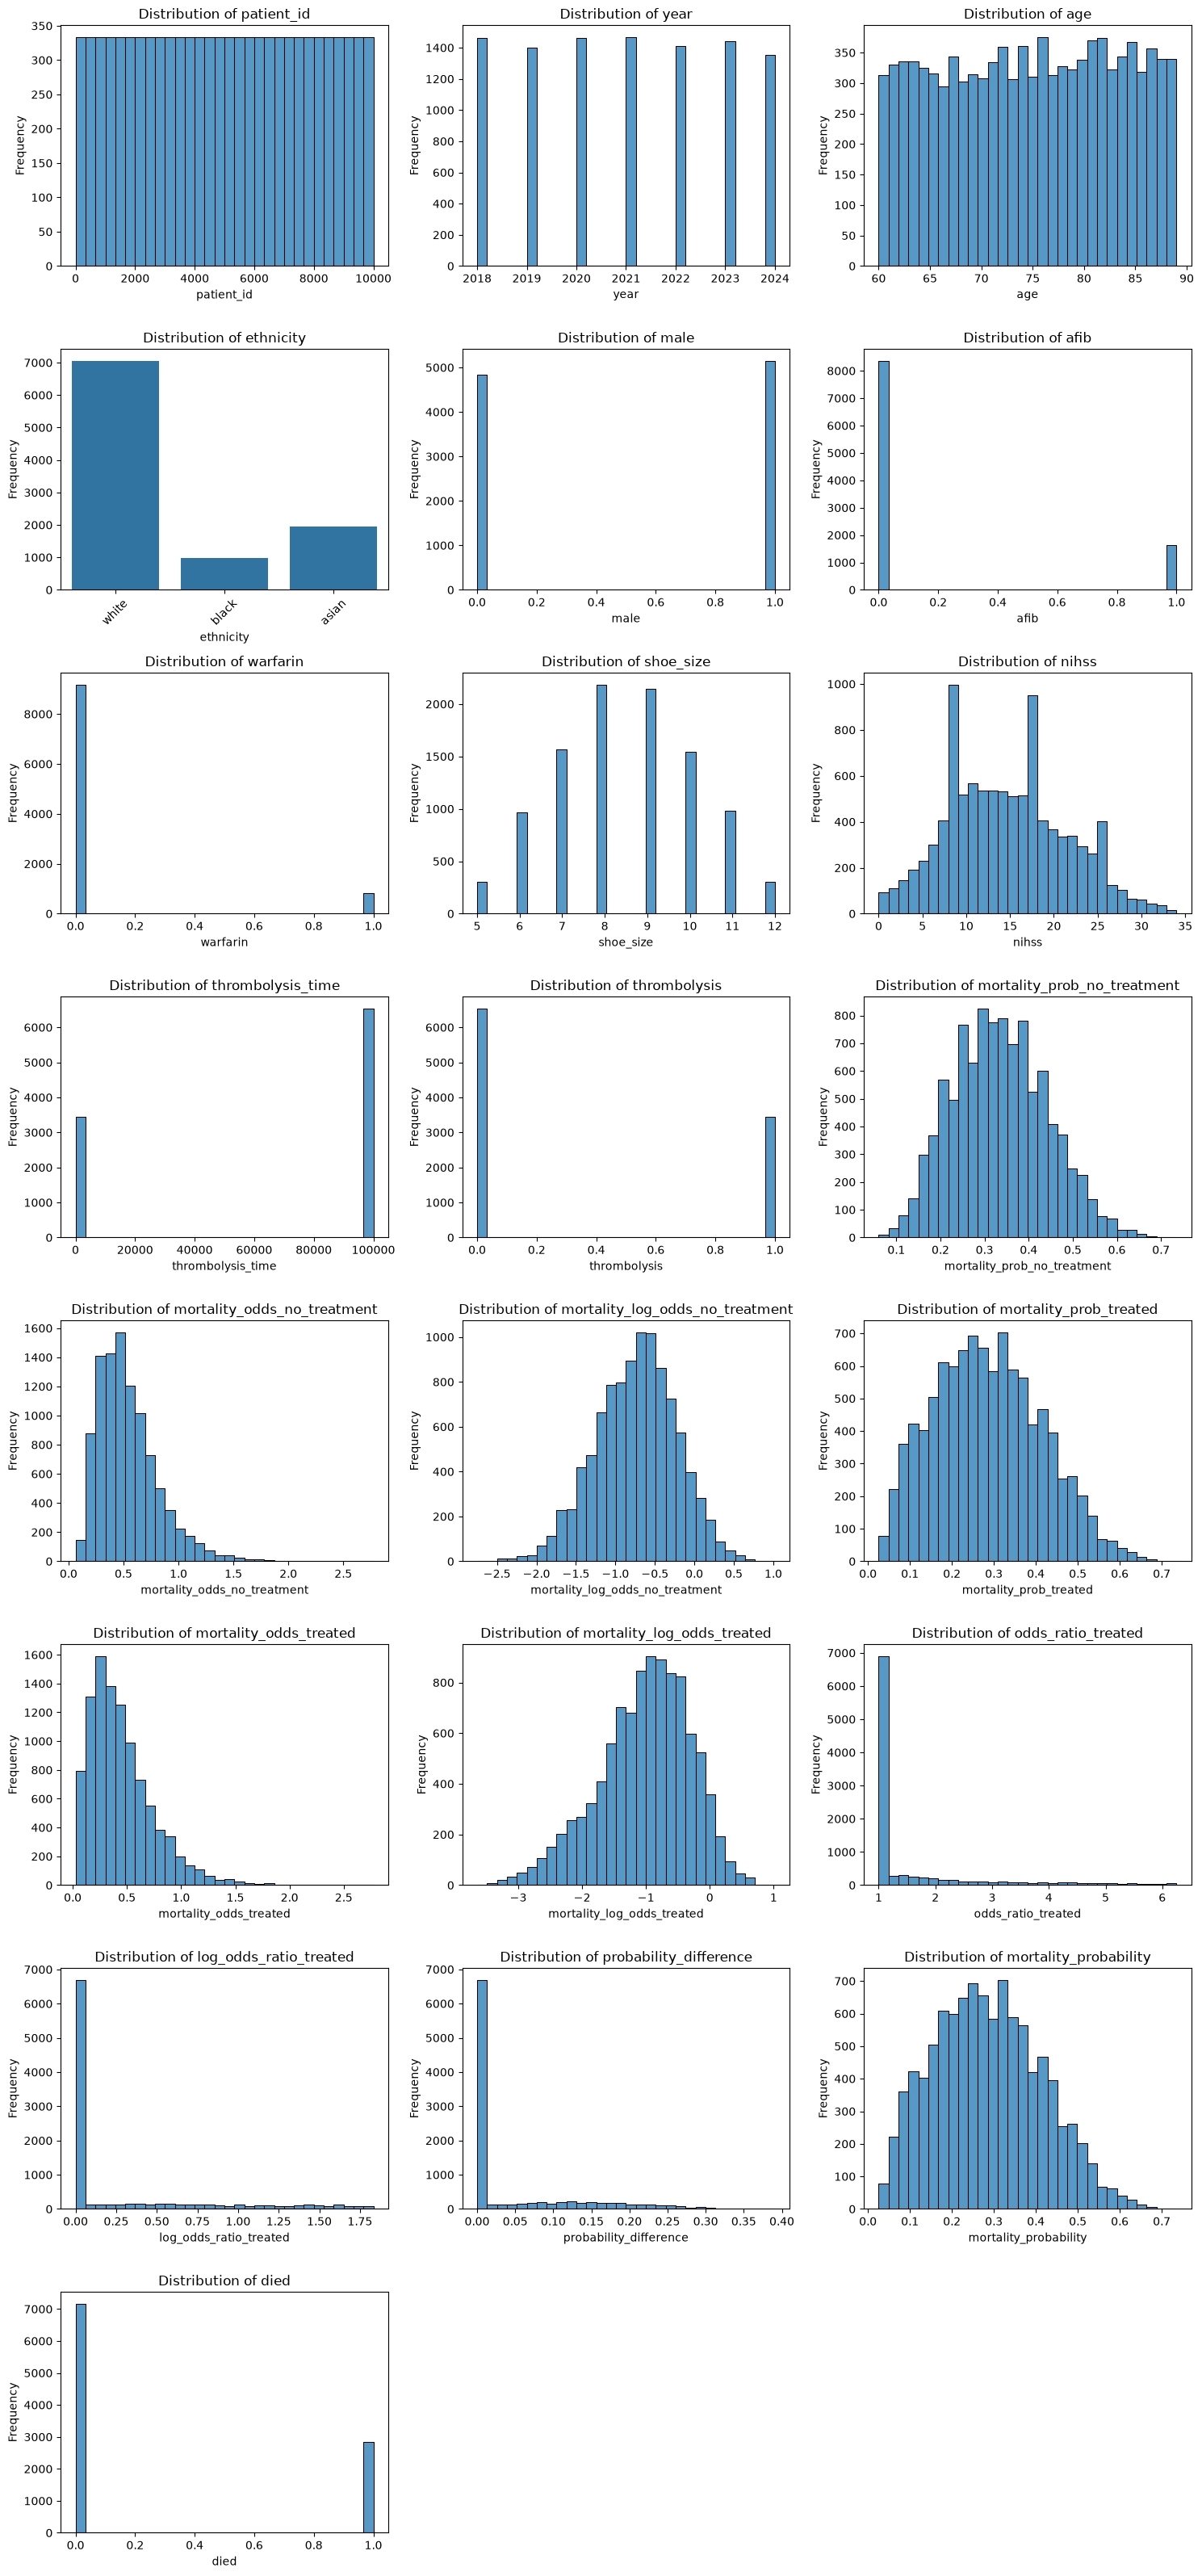

In [4]:
# Plot the distributions of all the variables in the dataset

ncols = 3
nrows = math.ceil(len(df.columns) / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = axes.ravel()

for ax, col in zip(axes, df.columns):
    if pd.api.types.is_numeric_dtype(df[col]):
        sns.histplot(data=df, x=col, kde=False, bins=30, ax=ax)
    else:
        sns.countplot(data=df, x=col, ax=ax)
        ax.tick_params(axis="x", rotation=45)

    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

for ax in axes[len(df.columns):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()